# 🐢 EPOCH Pilot Task Week 3
> 주제: 카드 이탈 데이터에 기반한 이탈 예측 모델 구축 및 고객 유형별 이탈 요인 분석

라이브러리 및 데이터 불러오기

In [1]:
# 필요한 패키지
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, recall_score, precision_score, precision_recall_curve, average_precision_score, roc_curve, auc  

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/card_engineered.csv')

### TASK 0: 모델 선정하기

이탈 여부를 예측하는 모델 = 분류 모델

앞서 변수들 간 다중공선성이 높았기 때문에, 이에 강한 RF, XGB, LGBM의 성능을 각각 살펴보자.

> 평가 지표 설명

* Precision: 모델이 이탈 고객이라고 예측한 사람 중 실제 이탈 고객의 비율. (TP)/(TP+FP)
* Recall: 실제 이탈 고객 중 모델이 이탈이라고 잡아낸 비율. (TP)/(TP+FN)
* F1-score: Precision과 Recall의 조화평균. 두 지표 간 균형을 평가하는 지표.

> 데이터 분리 및 인코딩

데이터를 먼저 분할하고 인코딩해야 데이터 누수(leakage)를 방지할 수 있다

In [ ]:
# 1. 3분할로 데이터 쪼개기
X = df.drop('churn', axis=1)
y = df['churn']

# 먼저 Test를 떼어내기(20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 남은 80%를 Train(60%)과 Valid(20%)로 나누기
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 2. 인코딩 동기화 (Train 기준으로 맞춤)
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_valid_enc = pd.get_dummies(X_valid, drop_first=True).reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc  = pd.get_dummies(X_test,  drop_first=True).reindex(columns=X_train_enc.columns, fill_value=0)

#### 1. Random Forest

RandomizedSearchCV를 통해 최적의 파라미터 찾고, 이를 적용한 모델의 성능 평가

In [5]:
# 1. 탐색할 파라미터 범위 설정 (나사 조절 범위)
param_dist = {
    'n_estimators': [100, 200, 300, 500], # 나무 개수
    'max_depth': [None, 10, 20, 30],      # 나무 깊이
    'min_samples_split': [2, 5, 10],      # 가지를 치기 위한 최소 샘플 수
    'max_features': ['sqrt', 'log2']      # 각 나무가 사용할 변수 개수
}

# 2. 자동 튜닝 알고리즘 설정
# scoring='recall'로 설정하여 이탈자를 잘 잡는 최적의 조합을 찾습니다.
# cv=5로 Train 데이터 안에서만 5조각으로 쪼개서 튜닝한다
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. 학습 진행
rf_random_search.fit(X_train_enc, y_train)

# 4. 최적의 모델과 결과 확인
best_rf = rf_random_search.best_estimator_
print(f"✅ [RandomForest] 최적 파라미터: {rf_random_search.best_params_}")

# 5. Valid 셋으로 '진짜 성능' 평가
y_val_pred = best_rf.predict(X_valid_enc)

print(f"\n📊 Validation 셋 Recall: {recall_score(y_valid, y_val_pred):.4f}")
print("\n[Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred))


# 6. 변수 중요도 확인
importances = pd.Series(best_rf.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)
print("\n--- [RandomForest] 변수 중요도 TOP 10 ---")
print(importances.head(10))

print("\n--- [RandomForest] 중요도 하위 변수 (삭제 고려 대상) ---")
print(importances.tail(10))

✅ [RandomForest] 최적 파라미터: {'n_estimators': 500, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 30}

📊 Validation 셋 Recall: 0.7883

[Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1700
           1       0.91      0.79      0.85       326

    accuracy                           0.95      2026
   macro avg       0.94      0.89      0.91      2026
weighted avg       0.95      0.95      0.95      2026


--- [RandomForest] 변수 중요도 TOP 10 ---
total_trans_amt      0.135503
total_trans_cnt      0.113419
revolving_balance    0.109646
activity_score       0.108325
monthly_trans        0.069497
product_count        0.068721
avg_trans_amt        0.064706
utilization_ratio    0.063205
amt_change_q4_q1     0.056181
spending_ratio       0.042148
dtype: float64

--- [RandomForest] 중요도 하위 변수 (삭제 고려 대상) ---
income_$40K - $60K         0.002195
income_Unknown             0.002100
education_Unknown    

#### 2. XGBoost

In [6]:
# 1. 탐색할 파라미터 범위 설정 
xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],    # 나무 개수
    'max_depth': [3, 5, 7, 10],              # 나무 깊이 (RF보다 보통 얕게 설정)
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # 학습률 (보폭)
    'subsample': [0.6, 0.8, 1.0],            # 데이터 샘플링 비율 (과적합 방지)
    'colsample_bytree': [0.6, 0.8, 1.0]      # 사용할 변수 비율 (과적합 방지)
}

# 2. 자동 튜닝 알고리즘 설정
xgb_random_search = RandomizedSearchCV(
    # eval_metric='logloss'는 최신 버전의 불필요한 경고 메시지를 방지합니다.
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. 학습 진행
xgb_random_search.fit(X_train_enc, y_train)

# 4. 최적의 모델과 결과 확인
best_xgb = xgb_random_search.best_estimator_
print(f"✅ [XGBoost] 최적 파라미터: {xgb_random_search.best_params_}")

# 5. Valid 셋으로 '진짜 성능' 평가
y_val_pred_xgb = best_xgb.predict(X_valid_enc)

print(f"\n📊 [XGBoost] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_xgb):.4f}")
print("\n[Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_xgb))

# 6. 변수 중요도 확인
xgb_importances = pd.Series(best_xgb.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)
print("\n--- [XGBoost] 변수 중요도 TOP 10 ---")
print(xgb_importances.head(10))

print("\n--- [XGBoost] 중요도 하위 변수 (삭제 고려 대상) ---")
print(xgb_importances.tail(10))

✅ [XGBoost] 최적 파라미터: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

📊 [XGBoost] Validation 셋 Recall: 0.8620

[Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1700
           1       0.92      0.86      0.89       326

    accuracy                           0.97      2026
   macro avg       0.95      0.92      0.94      2026
weighted avg       0.97      0.97      0.97      2026


--- [XGBoost] 변수 중요도 TOP 10 ---
total_trans_cnt        0.219417
revolving_balance      0.146307
activity_score         0.097465
product_count          0.092078
avg_trans_amt          0.051024
total_trans_amt        0.046606
amt_change_q4_q1       0.030968
inactive_12m           0.025129
income_$80K - $120K    0.024505
age                    0.021241
dtype: float32

--- [XGBoost] 중요도 하위 변수 (삭제 고려 대상) ---
income_$40K - $60K        0.008544
education_Unknown         

#### 3. LightGBM

In [7]:
# 1. 탐색할 파라미터 범위 설정 (LightGBM 맞춤형)
lgbm_param_dist = {
    'n_estimators': [100, 200, 300, 500],    # 나무 개수
    'max_depth': [-1, 5, 10, 20],            # 나무 깊이 (-1은 제한 없음을 의미)
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # 학습률
    'num_leaves': [31, 63, 127],             # 하나의 트리가 가질 수 있는 최대 잎의 수 (LGBM 핵심)
    'subsample': [0.6, 0.8, 1.0],            # 데이터 샘플링 비율
    'colsample_bytree': [0.6, 0.8, 1.0]      # 사용할 변수 비율
}

# 2. 자동 튜닝 알고리즘 설정
lgbm_random_search = RandomizedSearchCV(
    # verbose=-1 은 LightGBM 특유의 길고 복잡한 학습 로그(경고창)를 숨겨줍니다.
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. 학습 진행
lgbm_random_search.fit(X_train_enc, y_train)

# 4. 최적의 모델과 결과 확인
best_lgbm = lgbm_random_search.best_estimator_
print(f"✅ [LightGBM] 최적 파라미터: {lgbm_random_search.best_params_}")

# 5. Valid 셋으로 '진짜 성능' 평가
y_val_pred_lgbm = best_lgbm.predict(X_valid_enc)

print(f"\n📊 [LightGBM] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_lgbm):.4f}")
print("\n[Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_lgbm))

# 6. 변수 중요도 확인
lgbm_importances = pd.Series(best_lgbm.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)
print("\n--- [LightGBM] 변수 중요도 TOP 10 ---")
print(lgbm_importances.head(10))

print("\n--- [LightGBM] 중요도 하위 변수 (삭제 고려 대상) ---")
print(lgbm_importances.tail(10))

✅ [LightGBM] 최적 파라미터: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 20, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

📊 [LightGBM] Validation 셋 Recall: 0.8712

[Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1700
           1       0.92      0.87      0.90       326

    accuracy                           0.97      2026
   macro avg       0.95      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026


--- [LightGBM] 변수 중요도 TOP 10 ---
total_trans_amt      1142
amt_change_q4_q1     1063
avg_trans_amt         770
age                   551
revolving_balance     549
spending_ratio        536
activity_score        524
credit_limit          512
monthly_trans         485
total_trans_cnt       484
dtype: int32

--- [LightGBM] 중요도 하위 변수 (삭제 고려 대상) ---
education_High School      29
income_$40K - $60K         28
education_Unknown          26
income_Unkn

LightGBM으로 최종 결정.

: precision, recall, f1-score 모두 가장 높게 나타났다.

: 추가로, 3개 모델 모두 거래 관련 변수를 가장 중요하게 판단했고, 카드 등급의 중요도가 가장 낮게 나타났다. 이후 변수 선택에 있어 적용할 것.

### TASK 1: 모델 학습

> 변수 중요도 확인 및 변수 제거

LightGBM 모델에서 평가한 변수의 중요도를 확인해보자

/tmp/ipykernel_290/1240082857.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lgbm_importances.head(20).values, y=lgbm_importances.head(20).index, palette='viridis')


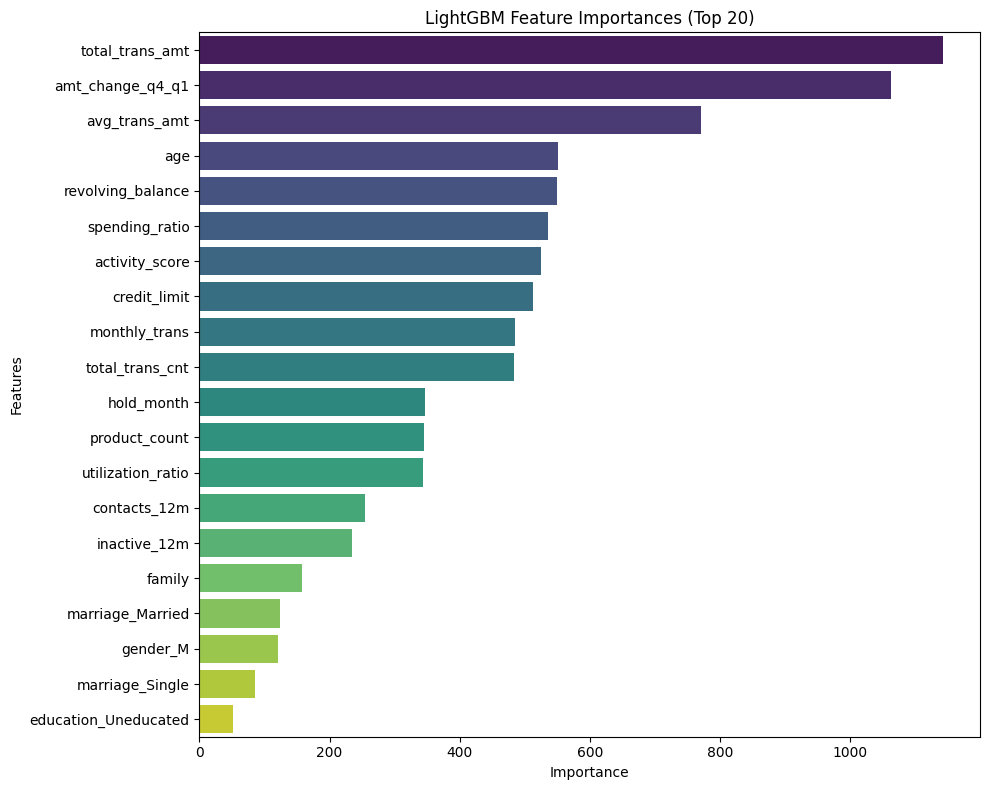


--- [LightGBM] 중요도 0 인 변수들 (2개) ---
['card_category_Gold', 'card_category_Platinum']

--- [LightGBM] 중요도 하위 15개 변수 ---
education_Uneducated       52
income_$80K - $120K        50
education_Graduate         49
income_Less than $40K      44
income_$60K - $80K         39
education_High School      29
income_$40K - $60K         28
education_Unknown          26
income_Unknown             26
marriage_Unknown           21
education_Doctorate        14
education_Post-Graduate    10
card_category_Silver        4
card_category_Gold          0
card_category_Platinum      0
dtype: int32


In [8]:
# 1. LightGBM 변수 중요도 추출 및 정렬
# (best_lgbm 모델과 X_train_enc를 사용)
lgbm_importances = pd.Series(best_lgbm.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)

# 2. 상위 20개 중요 변수 시각화 (어떤 변수가 하드캐리하고 있는지 확인)
plt.figure(figsize=(10, 8))
sns.barplot(x=lgbm_importances.head(20).values, y=lgbm_importances.head(20).index, palette='viridis')
plt.title('LightGBM Feature Importances (Top 20)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 3. 중요도가 아예 0인 변수들 확인
zero_importance_cols = lgbm_importances[lgbm_importances == 0].index.tolist()
print(f"\n--- [LightGBM] 중요도 0 인 변수들 ({len(zero_importance_cols)}개) ---")
print(zero_importance_cols)

# 4. 중요도 하위 15개 변수 확인 (0은 아니지만 기여도가 미미한 애들)
print("\n--- [LightGBM] 중요도 하위 15개 변수 ---")
print(lgbm_importances.tail(15))

카드 등급 관련 변수들은 중요도가 아주 낮게 나타난다.

하위에 존재하는 변수들(카드 등급, 교육 수준, 수익, 결혼)의 모든 세부 변수들의 중요도 확인해보자

In [9]:
# 1. 확인하고 싶은 원본 범주형 변수들의 이름 (접두사)
target_prefixes = ['card_category_', 'education_', 'income_', 'marriage_']

# 2. 인덱스(컬럼명)에 저 접두사들이 포함된 변수들만 필터링
target_importances = lgbm_importances[
    lgbm_importances.index.str.contains('|'.join(target_prefixes))
].sort_values(ascending=False)

# 3. 결과 출력
print("--- [LightGBM] 카테고리별 세부 변수 중요도 전체 확인 ---")
print(target_importances)

--- [LightGBM] 카테고리별 세부 변수 중요도 전체 확인 ---
marriage_Married           124
marriage_Single             86
education_Uneducated        52
income_$80K - $120K         50
education_Graduate          49
income_Less than $40K       44
income_$60K - $80K          39
education_High School       29
income_$40K - $60K          28
education_Unknown           26
income_Unknown              26
marriage_Unknown            21
education_Doctorate         14
education_Post-Graduate     10
card_category_Silver         4
card_category_Gold           0
card_category_Platinum       0
dtype: int32


결혼 관련 변수의 경우 중요도가 높은 카테고리(싱글 vs 기혼) 존재하므로 그대로 유지

우선은 모든 변수의 중요도가 낮게 나타나는 카드 카테고리 관련 변수 모두 삭제하고 모델 성능 평가

In [10]:
# 1. 삭제할 변수 리스트
drop_cols = ['card_category_Silver', 'card_category_Gold', 'card_category_Platinum']

# 2. Train, Valid, Test 모두에서 동일하게 삭제
X_train_slim = X_train_enc.drop(columns=drop_cols, errors='ignore')
X_valid_slim = X_valid_enc.drop(columns=drop_cols, errors='ignore')
X_test_slim  = X_test_enc.drop(columns=drop_cols, errors='ignore')

print(f"🔥 피처 다이어트 완료!")
print(f"기존 컬럼 수: {X_train_enc.shape[1]}개 -> Slim 컬럼 수: {X_train_slim.shape[1]}개")
print(f"총 {X_train_enc.shape[1] - X_train_slim.shape[1]}개의 불필요한 노이즈가 제거되었습니다.")

🔥 피처 다이어트 완료!
기존 컬럼 수: 34개 -> Slim 컬럼 수: 31개
총 3개의 불필요한 노이즈가 제거되었습니다.


In [11]:
# 1. 1단계에서 사용했던 파라미터 탐색 범위 그대로 가져오기
lgbm_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 5, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 63, 127],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 2. 자동 튜닝 알고리즘 설정 (Slim 데이터 기준)
lgbm_slim_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. Slim Train 데이터로 학습 진행
print("🚀 Slim 데이터로 LightGBM 하이퍼파라미터 튜닝을 시작합니다...")
lgbm_slim_search.fit(X_train_slim, y_train)

# 4. 최적의 Slim 모델 추출
best_lgbm_slim = lgbm_slim_search.best_estimator_
print(f"\n✅ [Slim 모델] 최적 파라미터: {lgbm_slim_search.best_params_}")

# 5. ⭐️ Valid 셋으로 '진짜 성능' 평가
y_val_pred_slim = best_lgbm_slim.predict(X_valid_slim)

print(f"\n📊 [Slim 모델] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_slim):.4f}")
print("\n[Slim 모델 Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_slim))

🚀 Slim 데이터로 LightGBM 하이퍼파라미터 튜닝을 시작합니다...

✅ [Slim 모델] 최적 파라미터: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

📊 [Slim 모델] Validation 셋 Recall: 0.8804

[Slim 모델 Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1700
           1       0.93      0.88      0.90       326

    accuracy                           0.97      2026
   macro avg       0.95      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



precision, recall이 0.1씩 증가했다.

하위에 있던 변수를 몇개 더 제거해볼까?

In [12]:
# 1. 삭제할 변수 리스트 (중요도 30 미만 모두)
drop_cols = [
    'card_category_Silver', 'card_category_Gold', 'card_category_Platinum',
    'education_High School', 'income_$40K - $60K', 'education_unknown', 'income_unnknown',
    'marriage_unknown', 'education_Doctorate', 'education_Post-Graduate'
]

# 2. Train, Valid, Test 모두에서 동일하게 날리기!
X_train_slim = X_train_enc.drop(columns=drop_cols, errors='ignore')
X_valid_slim = X_valid_enc.drop(columns=drop_cols, errors='ignore')
X_test_slim  = X_test_enc.drop(columns=drop_cols, errors='ignore')

print(f"🔥 피처 다이어트 완료!")
print(f"기존 컬럼 수: {X_train_enc.shape[1]}개 -> Slim 컬럼 수: {X_train_slim.shape[1]}개")
print(f"총 {X_train_enc.shape[1] - X_train_slim.shape[1]}개의 불필요한 노이즈가 제거되었습니다.")

🔥 피처 다이어트 완료!
기존 컬럼 수: 34개 -> Slim 컬럼 수: 27개
총 7개의 불필요한 노이즈가 제거되었습니다.


💡 잠깐, 파생변수의 특정 범주만 지워도 되는 걸까?

: 완벽하게 가능하다! 예를 들어 education_Doctorate를 지우게 되면, 박사 학위를 가진 사람들은 남은 education 관련 컬럼이 모두 0이 된다. 이는 기준값(Reference)과 동일한 그룹으로 묶이게 됨을 의미한다. 즉, 모델에게 **"박사 학위인지 아닌지는 이탈 예측에 안 중요하니까, 그냥 평범한 기본 그룹이랑 똑같이 취급해!"**라고 똑똑하게 알려주는 것과 같다.

In [13]:
# 1. 1단계에서 사용했던 파라미터 탐색 범위 그대로 가져오기
lgbm_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [-1, 5, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 63, 127],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# 2. 자동 튜닝 알고리즘 설정 (Slim 데이터 기준)
lgbm_slim_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=10, cv=5, scoring='recall', n_jobs=-1, random_state=42
)

# 3. Slim Train 데이터로 학습 진행
print("🚀 Slim 데이터로 LightGBM 하이퍼파라미터 튜닝을 시작합니다...")
lgbm_slim_search.fit(X_train_slim, y_train)

# 4. 최적의 Slim 모델 추출
best_lgbm_slim = lgbm_slim_search.best_estimator_
print(f"\n✅ [Slim 모델] 최적 파라미터: {lgbm_slim_search.best_params_}")

# 5. ⭐️ Valid 셋으로 '진짜 성능' 평가
y_val_pred_slim = best_lgbm_slim.predict(X_valid_slim)

print(f"\n📊 [Slim 모델] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_slim):.4f}")
print("\n[Slim 모델 Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_slim))

🚀 Slim 데이터로 LightGBM 하이퍼파라미터 튜닝을 시작합니다...

✅ [Slim 모델] 최적 파라미터: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 20, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

📊 [Slim 모델] Validation 셋 Recall: 0.8865

[Slim 모델 Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1700
           1       0.93      0.89      0.91       326

    accuracy                           0.97      2026
   macro avg       0.96      0.94      0.95      2026
weighted avg       0.97      0.97      0.97      2026



recall과 f1-score가 더 올랐다~

> 불균형 데이터 가중치 조절

이탈한 고객이 16%밖에 되지 않는 불균형 데이터이므로, 이탈자에게 더 높은 가중치를 줘서 Accuracy 조정.

(불균형 상태에서 그냥 전부 다 이탈 안한다고 하면 accuracy 어느 정도 높을 테니까)

In [14]:
# 1. 훈련 데이터의 불균형 비율(가중치) 계산
# 가중치 = (정상 고객 수) / (이탈 고객 수)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
optimal_weight = neg_count / pos_count

print(f"⚖️ 정상 고객 수: {neg_count}명, 이탈 고객 수: {pos_count}명")
print(f"⚖️ 권장되는 scale_pos_weight: {optimal_weight:.2f}")

# 2. 3단계에서 찾은 최적의 파라미터 가져오기
best_params = best_lgbm_slim.get_params()

# 3. 모델에 가중치 덮어씌우기
best_params['scale_pos_weight'] = optimal_weight

# 4. 가중치가 적용된 새로운 모델 생성 및 학습
lgbm_weighted = LGBMClassifier(**best_params)
lgbm_weighted.fit(X_train_slim, y_train)

# 5. Valid 셋으로 성능 평가
y_val_pred_weighted = lgbm_weighted.predict(X_valid_slim)

print(f"\n📊 [가중치 적용 모델] Validation 셋 Recall: {recall_score(y_valid, y_val_pred_weighted):.4f}")
print(f"📊 [가중치 적용 모델] Validation 셋 Precision: {precision_score(y_valid, y_val_pred_weighted):.4f}")
print("\n[가중치 적용 모델 Validation 셋 Classification Report]")
print(classification_report(y_valid, y_val_pred_weighted))

⚖️ 정상 고객 수: 5099명, 이탈 고객 수: 976명
⚖️ 권장되는 scale_pos_weight: 5.22

📊 [가중치 적용 모델] Validation 셋 Recall: 0.8957
📊 [가중치 적용 모델] Validation 셋 Precision: 0.9241

[가중치 적용 모델 Validation 셋 Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1700
           1       0.92      0.90      0.91       326

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.95      2026
weighted avg       0.97      0.97      0.97      2026



precision 조금 줄고 recall이 0.9까지 올랐다 (trade-off)

카드 이탈 문제는 현실적으로 이탈하면 회복이 어렵고, (retention 비용 < 이탈 손실)이라서 Recall을 우선시하고 그 다음 적절한 수준의 precision을 고려하는 편이다.

여기서 추가적인 생각: 이탈 고객을 찾아내서 방어했을 때 얻는 이득 vs 고객 1명에게 해지를 방지하기 위한 서비스를 제공하는 비용 사이 절충은 어느 정도여야 이상적일까?

.. 추후에 생각

### TASK 2: 모델 평가

Test set으로 모델을 평가해보자.

* 1: 성능 지표인 ROC-AUC Score, PR-AUC Score 확인 (PR-AUC Score은 불균형 데이터에서 더 좋은 성능 지표이다. 왜냐하면 양성(이탈) 클래스에 더 집중하기 때문에!)
* 2: Confusion Matrix 확인
* 3: Precision(정밀도), Recall(재현율), f1-score 확인

> ROC/PR-AUC Score

In [21]:
# 1. Test 셋 개봉 및 예측
final_model = lgbm_weighted 

y_test_pred = final_model.predict(X_test_slim)
y_test_proba = final_model.predict_proba(X_test_slim)[:, 1]

# 2. 핵심 성능 지표 출력
# ROC-AUC Score
print("🚀 [최종 Test Set 성능 평가 보고서] 🚀")
print("-" * 50)
print(f"✅ ROC-AUC Score : {roc_auc_score(y_test, y_test_proba):.4f}")

# 불균형 데이터의 핵심 지표(PR-AUC Score)
print(f"✅ PR-AUC Score  : {average_precision_score(y_test, y_test_proba):.4f}")
print("-" * 50)

print("\n[Classification Report]")
print(classification_report(y_test, y_test_pred))

🚀 [최종 Test Set 성능 평가 보고서] 🚀
--------------------------------------------------
✅ ROC-AUC Score : 0.9898
✅ PR-AUC Score  : 0.9575
--------------------------------------------------

[Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.90      0.88      0.89       325

    accuracy                           0.97      2026
   macro avg       0.94      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026



결과 해석

ROC-AUC Score : 0.9898 
* 임의의 이탈자와 정상 고객을 비교했을 때, 모델이 이탈 고객을 더 높은 위험도로 판단할 확률이 약 99%로 매우 높은 구분 능력을 보인다.

PR-AUC Score  : 0.9575 
* 일탈 고객 탐지에서 Precision과 Recall 간 균형이 우수하다. 높은 Recall을 유지하면서도, 불필요한 오탐지를 효과적으로 억제한다.

⚠️ F1-score와 PR-AUC의 차이?

F1-score: 특정 임계값(예: 0.5) 딱 하나에서 측정된 **'현재 세팅의 단편적인 성적'**

PR-AUC: 모든 임계값(0~1)을 훑으며 계산한 면적으로, 모델이 가진 **'근본적인 잠재력'**

F1은 실무에서 **"지금 당장 이 세팅으로 배포해도 될까?"**를 결정할 때 확인

PR-AUC는 **"여러 모델 중 어떤 모델의 체급이 더 높은가?"**를 비교할 때 가장 신뢰하는 지표

요약하자면, '특정 지점의 컨디션(F1)'과 '모델 전체의 평균 기량(PR-AUC)' 차이

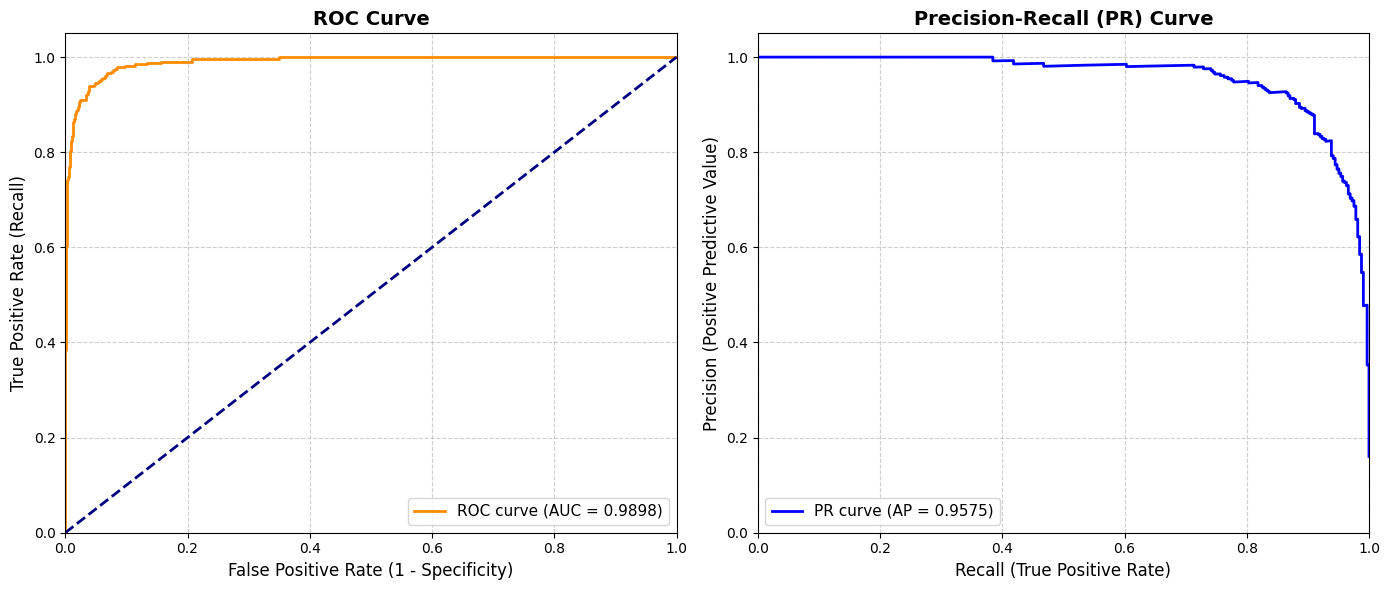

In [23]:
# 1. 평가 지표 계산
# ROC Curve 데이터
fpr, tpr, roc_thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# PR Curve 데이터
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)

# 2. 1행 2열 Subplot 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# PR Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {pr_auc:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[1].set_title('Precision-Recall (PR) Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower left", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

# 레이아웃 겹침 방지 및 출력
plt.tight_layout()
plt.show()

* ROC-Curve: 선이 좌측 상단에 달라붙어 있다. 이탈 고객에게 더 높은 위험 점수를 부여할 확률이 약 99%이다. (변별력)

* PR-Curve: 가로축이 0.8~0.9(이탈자 80~90% 검출)에 도달할 때까지 세로축(정밀도)이 1.0 부근을 유지하고 있다.(정교함)

이탈 고객을 90% 가까이 탐지하면서, 정상 고객을 이탈 고객으로 잘못 탐지하는 것을 효과적으로 억제하고 있다.

> Confusion Matrix

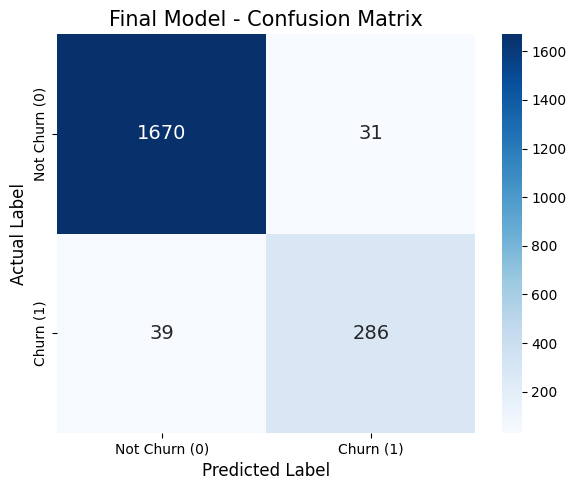

In [22]:
# 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Churn (0)', 'Churn (1)'], 
            yticklabels=['Not Churn (0)', 'Churn (1)'],
            annot_kws={"size": 14})
plt.title('Final Model - Confusion Matrix', fontsize=15)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

혼동 행렬 해석

True Positive(TP), 우측 하단: 286명
* 실제로 카드를 해지하려던 고객 중 286명을 정확히 찾아냈다.
* 이탈자 총 325명 중 88%를 잡아냈다.

True Negative(TN), 좌측 상단: 1,670명
* 정상 고객 1,670명을 정확하게 안 떠날 사람으로 분류했다.

False Positive(FP), 우측 상단: 31명
* 실제로는 떠나지 않을 고객인데, 모델이 이탈할 것이라고 오해한 케이스
* 전체 정상 고객(1,701명) 중 단 1.8%(31명)에게만 오탐지가 일어났다. 

False Negative(FN), 좌측 하단: 39명
* 모델이 정상 고객이라고 판단했는데, 카드를 해지한 고객들

이후 확인할 것

: 어떤 고객이 이탈하는가? 이탈 징후는 무엇인가?

In [20]:
# 다음 파일에서 작업하기 위해 데이터 저장
#import joblib

# 1. 구글 드라이브 저장 경로 설정 (VS Code - Colab 환경)
#drive_path = '/content/drive/MyDrive/'

# 2. 모델 저장 (가중치 적용된 최종 LightGBM)
#joblib.dump(lgbm_weighted, drive_path + 'best_lgbm_model.pkl')

# 3. 훈련용(Train), 검증용(Valid), 테스트용(Test) 데이터 모두 CSV로 저장
# Train Set
#X_train_slim.to_csv(drive_path + 'X_train_slim.csv', index=False)
#y_train.to_csv(drive_path + 'y_train.csv', index=False)

# Valid Set 
#X_valid_slim.to_csv(drive_path + 'X_valid_slim.csv', index=False)
#y_valid.to_csv(drive_path + 'y_valid.csv', index=False)

# Test Set
#X_test_slim.to_csv(drive_path + 'X_test_slim.csv', index=False)
#y_test.to_csv(drive_path + 'y_test.csv', index=False)

#print("✅ 모든 데이터와 모델이 구글 드라이브에 완벽하게 백업되었습니다!")